# Problem 4: Fourier transform (3 pts)

### <div align="right"> &copy; Yurii Laba & Rostyslav Hryniv, 2023 </div>

## Completed by:   
*   First team member
*   Second team member

### Description

#### The aim of this task is to implement continuous and discrete Fourier transforms and understand on practical examples some theoretical phenomena we discussed in lectures.

#### For this task of your homework you can get 3 points. Do not forget to save and rename the notebook before making any changes!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
%matplotlib inline
import random

random.seed(42)

## Task 1. Continuous signals, pure tones, and Fourier series (1 pt)

An analog audiosignal $\mathbf{x}$ of duration $T$ is a real-valued (usually continuous) function over $[0,T]$, whose value $\mathbf{x}(t)$ at a time moment $t$ represents the amplitude of air pressure variations, i.e., the change in air pressure with respect to some reference value. These pressure variations cause virbations of the ear drums, which are converted into electromagnetic impulses that are then sent to our brain.

Physical laws of gas dynamics imply that each such signal can be represented as a superposition of periodic ***pure tones*** $\sin( \omega t + \phi)$, i.e.,
$$\mathbf{x}(t) = \sum a_k \sin(\omega_k t + \phi_k).$$
Here $a_k$ is the amplitude of the respective pure wave of ***frequency*** $\omega_k/2\pi$ Hz (Hertz, cycles per second) and phase shift of $\phi_k$ radians. Observe that a wave of frequency $\omega_k/2\pi$ Hz has a period of $2\pi/\omega_k$ seconds.

The signal $\mathbf{x}$ can be regarded as periodic of period $T$ and can be represented via the ***Fourier series***
$$
  \mathbf{x}(t) = \frac{a_0}{2} + \sum_k a_k \cos(2\pi k t / T) + \sum_k b_k \sin(2\pi k t/T),
$$
where
$$
 a_k:= \frac{2}{T} \int_0^T f(s)\cos(2\pi ks/T)\,ds,  \qquad b_k:= \frac{2}{T} \int_0^T f(s)\sin(2\pi ks/T)\,ds
$$
are the ***Fourier coefficients***.


---
### Task 1.1.
Consider the signal
$$
  \mathbf{x}(t) = 0.5 \sin(2t) - \sin(3t) + n_t
$$
over the interval $[0,4\pi]$, where $n_t$ is the *white noise*, i.e., a family of independent Gaussian random variables $\mathcal{N}(0, \sigma^2)$ with $\sigma^2 = 0.01$.
- Generate the noiseles signal $\mathbf{x}$ and then add the noise to form $\mathbf{x}_\mathrm{noise}$
- Calculate the Fourier coefficients $a_k$ and $b_k$ of noiseless signal $\mathbf{x}$ for $k = 0,1, \dots, 200$ and plot them. Comment on any special features in the distribution of $a_k$ and $b_k$ you have noticed
- Calculate the Fourier coefficients $a_k$ and $b_k$ of the noisy signal $\mathbf{x}_\mathrm{noise}$ for $k = 0,1, \dots, 200$ and plot them. Comment on any special features in the distribution of $a_k$ and $b_k$ you have noticed
- Determine several (4-6) most important Fourier coefficients $a_k$ and $b_k$. What $k$ do they correspond to? What are the corresponding frequencies?
  
Use the grid of $200$ points $t_j$ for plotting and calculation of the Fourier coefficients (i.e., for numerical integration)

---

In [2]:
def signal(s):
  # ========= YOUR CODE STARTS HERE ========= #
  return 0.5 * np.sin(2*s) - np.sin(3*s)
  # ========== YOUR CODE ENDS HERE ========== #
N = 200

t = np.linspace(0, 4*np.pi, N+1)[:-1]
x = signal(t)

# ========= YOUR CODE STARTS HERE ========= #
x_noise = x + np.random.normal(0, 0.1, N)
# ========== YOUR CODE ENDS HERE ========== #

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-3278230964.py:3: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Original signal $\mathbf{x}$ and $\mathbf{x}_\mathrm{noise}$')


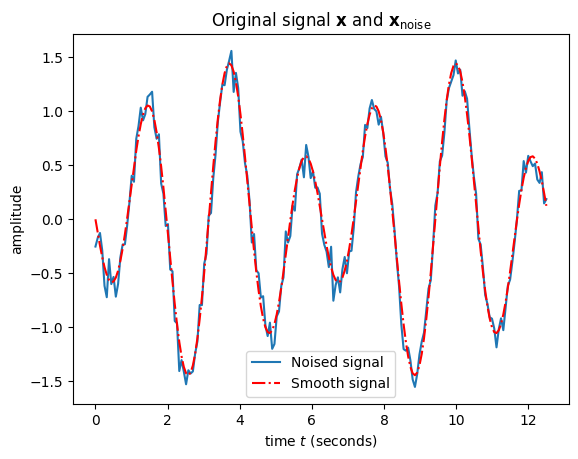

In [3]:
plt.plot(t, x_noise, label = "Noised signal")
plt.plot(t, x, "r-.", label = "Smooth signal")
plt.title('Original signal $\mathbf{x}$ and $\mathbf{x}_\mathrm{noise}$')
plt.xlabel("time $t$ (seconds)")
plt.ylabel("amplitude")
plt.legend()
plt.show()

In [12]:
########################################
#     Trigonometric Fourier coefficients
########################################

rng = np.arange(N).reshape(1, -1)

# cos_samples and sin_samples are N x N matrices with sampled cosines/sines written in rows

# ========= YOUR CODE STARTS HERE ========= #
# cos_samples[k, j] = cos(2*pi*k*t_j/T)
cos_samples = np.cos(2 * np.pi * rng.T @ rng / N)
sin_samples = np.sin(2 * np.pi * rng.T @ rng / N)
# ========== YOUR CODE ENDS HERE ========== #

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-86645977.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Trigonometric Fourier coefficients $a_k$ and $b_k$ for $\mathbf{x}$')


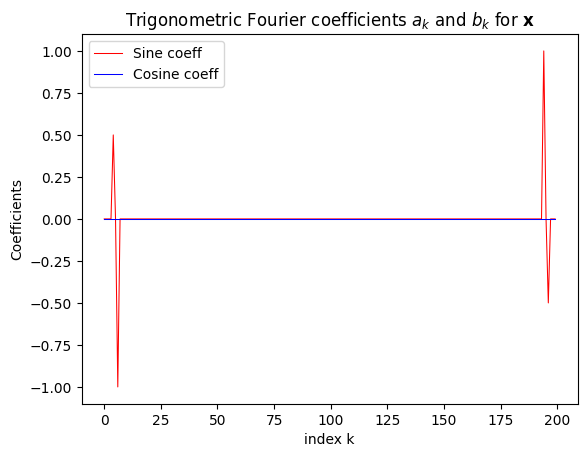

In [15]:
########################################
#  noiseless case
########################################

# ========= YOUR CODE STARTS HERE ========= #

a = (2/N) * (cos_samples @ x)    # the sequence of N cosine coefficients of signal x
b = (2/N) * (sin_samples @ x)    # the sequence of N sine coefficients of signal x
#a[0] = a[0] / 2  # adjust a_0

# Reshape to (N, 1) for compatibility

# ========== YOUR CODE ENDS HERE ========== #

plt.plot(range(N), b.T, "r", lw = 0.75, label = "Sine coeff")
plt.plot(range(N), a.T, "b", lw = 0.75, label = "Cosine coeff")
plt.xlabel("index k")
plt.ylabel("Coefficients")
plt.title('Trigonometric Fourier coefficients $a_k$ and $b_k$ for $\mathbf{x}$')
plt.legend()
plt.show()


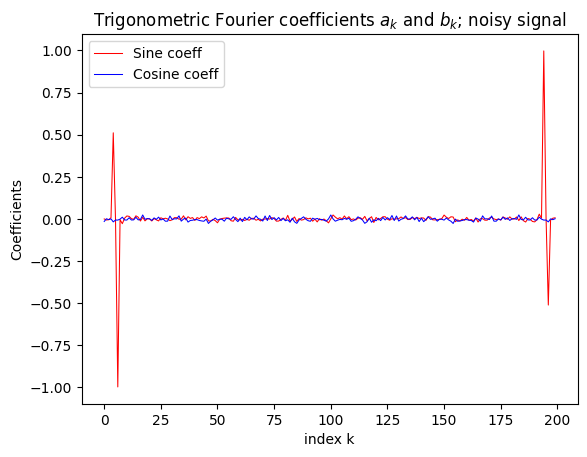

In [16]:
########################################
#  noisy signal
########################################

# ========= YOUR CODE STARTS HERE ========= #

a_noise = (2/N) * (cos_samples @ x_noise)   # the sequence of N cosine coefficients of noisy signal x_noise
b_noise = (2/N) * (sin_samples @ x_noise)   # the sequence of N sine coefficients of noisy signal x_noise
a_noise[0] = a_noise[0] / 2  # adjust a_0

# ========== YOUR CODE ENDS HERE ========== #

plt.plot(range(N), b_noise.T, "r", lw = 0.75, label = "Sine coeff")
plt.plot(range(N), a_noise.T, "b", lw = 0.75, label = "Cosine coeff")
plt.xlabel("index k")
plt.ylabel("Coefficients")
plt.title('Trigonometric Fourier coefficients $a_k$ and $b_k$; noisy signal')
plt.legend()
plt.show()


In [20]:
# Find most important coefficients
magnitude = np.sqrt(a_noise**2 + b_noise**2)
important_indices = np.argsort(magnitude)[-6:][::-1]

print("Most important Fourier coefficients:")
for idx in important_indices:
    freq = idx / (4*np.pi)  # frequency in Hz
    print(f"k={idx}: a_k={a_noise[idx]:.4f}, b_k={b_noise[idx]:.4f}, "
          f"magnitude={magnitude[idx]:.4f}, frequency={freq:.4f} Hz")

Most important Fourier coefficients:
k=6: a_k=-0.0069, b_k=-0.9975, magnitude=0.9975, frequency=0.4775 Hz
k=194: a_k=-0.0069, b_k=0.9975, magnitude=0.9975, frequency=15.4380 Hz
k=196: a_k=-0.0176, b_k=-0.5113, magnitude=0.5116, frequency=15.5972 Hz
k=4: a_k=-0.0176, b_k=0.5113, magnitude=0.5116, frequency=0.3183 Hz
k=115: a_k=-0.0262, b_k=0.0151, magnitude=0.0302, frequency=9.1514 Hz
k=85: a_k=-0.0262, b_k=-0.0151, magnitude=0.0302, frequency=6.7641 Hz


---

**For the noiseless signal,**
we observe only 4 non-zero coefficients out of 200.
The sine coefficients show two positive spikes (k=4 with b_k approx. 0.5 and k=194 with b_k approx. 1.0)
and two negative spikes (k=6 with b_k approx. -1.0 and k=196 with b_k approx. -0.5). All cosine
coefficients are essentially zero since the signal contains only sine terms. The
pairs (k=4, k=196) and (k=6, k=194) show mirror symmetry because for real signals
$$ c_{N-k} = conjugate(c_k) $$ The spike amplitudes match the signal components: 0.5 for
sin(2t) and 1.0 for sin(3t), with the negative sign correctly appearing at k=6
for -sin(3t).



**For the noisy signal,**
the same 4 dominant spikes remain clearly visible at k=4, 6, 194, 196 with similar amplitudes. However, small random fluctuations now appear across all frequencies in both sine and cosine coefficients, with typical noise amplitude around ±0.05. The noise is uniformly distributed across all frequencies, which is characteristic of white Gaussian noise, while the signal remains concentrated at specific frequencies.


**The 6 largest coefficients are at k=6, 4, 194, 196 (signal) and k=115, 85 (noise).** The coefficients at k=4 (0.318 Hz) and k=6 (0.477 Hz) correspond to the frequencies 2/(2π) and 3/(2π) from the original signal components 0.5*sin(2t) and -sin(3t). The pairs k=194 and k=196 are conjugate symmetry reflections with no independent physical meaning. The noise coefficients at k=85 and k=115 have magnitudes about 30 times smaller than the signal peaks, confirming that only k=4 and k=6 contain meaningful signal information.

---

---
### Task 1.2

- Construct approximations $\hat{\mathbf{x}}_n$ of $\mathbf{x}_{\mathrm{noise}}$ using $a_k$ and $b_k$ for $k = 0,1, \dots, n$, with $n=5, 10, 100, 200$
- Plot the original and reconstructed signals for $n = 5, 10, 100$, and $200$ and discuss the effect
- Calculate the accuracy of approximation based on the maximal value of $|\mathbf{x}_{\mathrm{noise}}(t_j) - \hat{\mathbf{x}}_n(t_j)|$  
- What goes wrong for $n=5$ and $n=200$? Can you explain strong change from $n=6$ to $n=7$? Also, increasing $n$ should improve proximity of $\hat{\mathbf{x}}_n$ and the original signal $\mathbf{x}_{\mathrm{noise}}$; however, $n=200$ gives very poor approximation.

Use the grid of $200$ points $t_j$ for plotting and calculation of the Fourier coefficients (i.e., numerical integration)

---

In [21]:
# Reconstruction of the signal using n sine and cosine Fourier coefficients
# Pay special attention to a_0!
def x_rec(n, a, b):
  # n is the number of coefficients a_k and b_k to be included
  # a is the 1d array of cosine coefficients
  # b is the 1d array of  sine  coefficients

  # ========= YOUR CODE STARTS HERE ========= #
  x_reconstructed = a[0] * np.ones_like(t)

  for k in range(1, n):
    x_reconstructed += a[k] * np.cos(2 * np.pi * k * t / (4*np.pi))
    x_reconstructed += b[k] * np.sin(2 * np.pi * k * t / (4*np.pi))

  return x_reconstructed
  # ========== YOUR CODE ENDS HERE ========== #

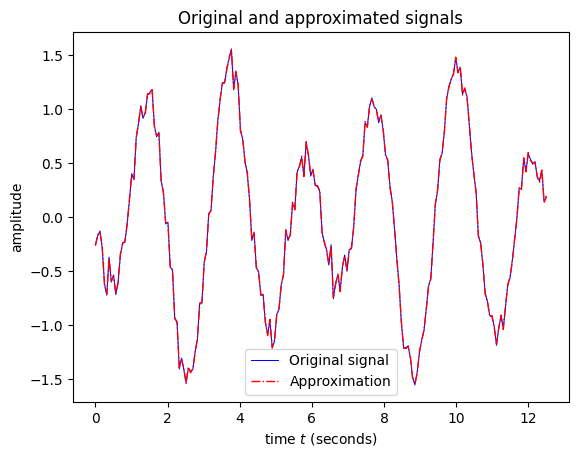

In [22]:
plt.plot(t, x_noise, 'b', lw= 0.75, label = "Original signal")
plt.plot(t, x_rec(100, a_noise, b_noise).T, 'r-.', lw = 1, label = "Approximation")
plt.title('Original and approximated signals')
plt.xlabel("time $t$ (seconds)")
plt.ylabel("amplitude")
plt.legend()
plt.show()

In [23]:
np.allclose(x_noise, x_rec(100, a_noise, b_noise), rtol=0.01)

False

In [24]:
np.max(np.abs(x_noise - x_rec(100, a_noise, b_noise)))

np.float64(0.011723106513079173)

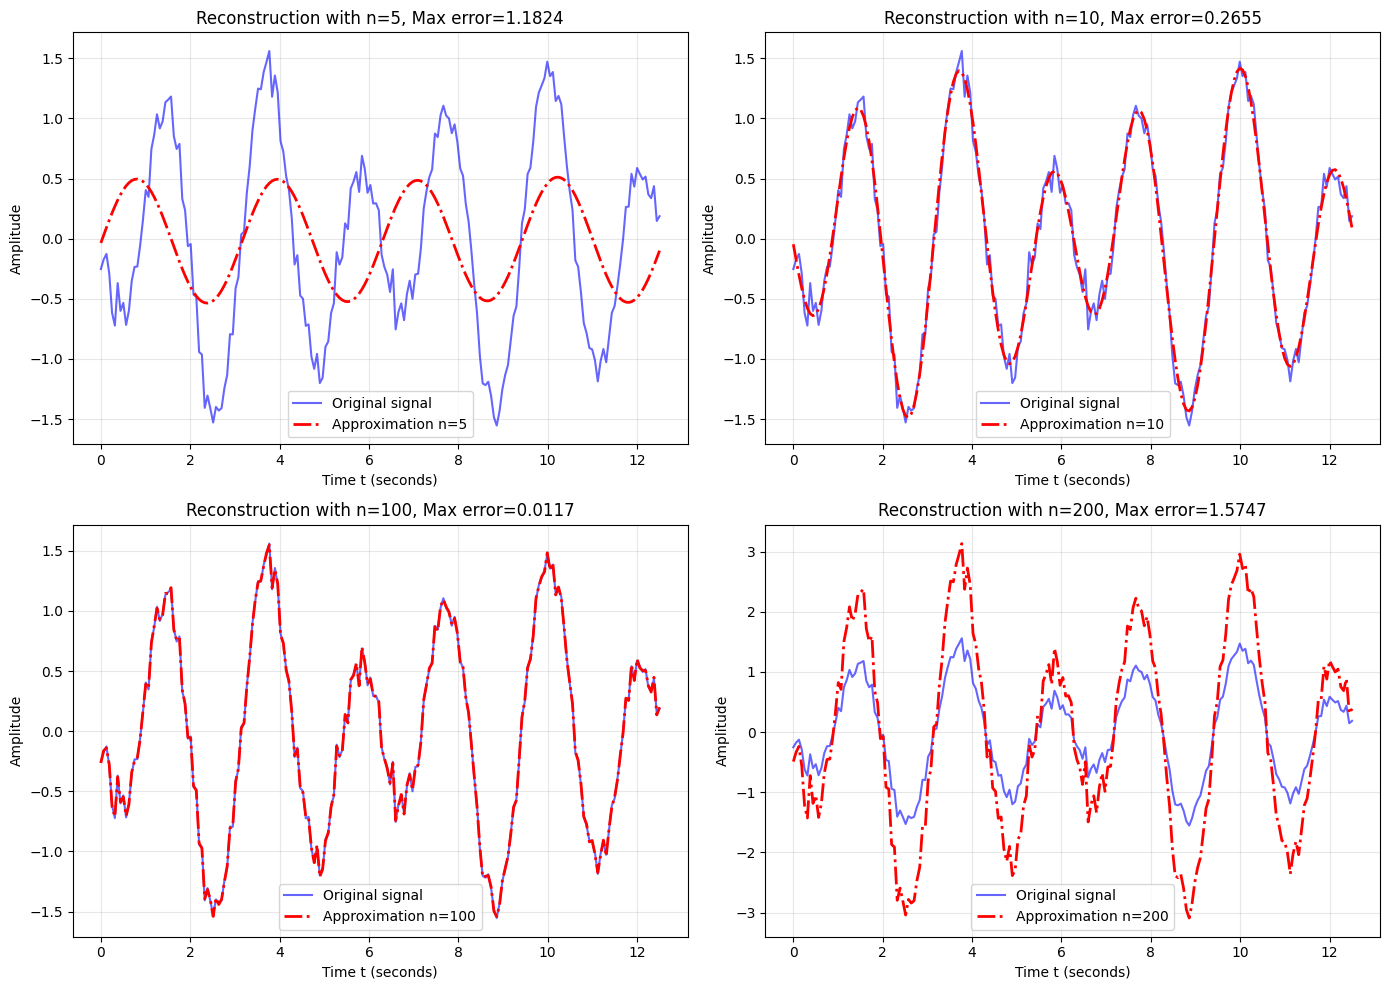

In [27]:
n_values = [5, 10, 100, 200]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, n in enumerate(n_values):
    x_approx = x_rec(n, a_noise, b_noise)
    max_error = np.max(np.abs(x_noise - x_approx))

    axes[i].plot(t, x_noise, 'b-', alpha=0.6, linewidth=1.5, label='Original signal')
    axes[i].plot(t, x_approx, 'r-.', linewidth=2, label=f'Approximation n={n}')
    axes[i].set_title(f'Reconstruction with n={n}, Max error={max_error:.4f}', fontsize=12)
    axes[i].set_xlabel('Time t (seconds)')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [25]:
n_values = [5, 6, 7, 10, 100, 200]

print("Reconstruction Errors:")
print(f"{'n':>4} | {'Max Error':>12} | {'Mean Error':>12}")
print("-" * 35)

for n in n_values:
    x_approx = x_rec(n, a_noise, b_noise)
    max_error = np.max(np.abs(x_noise - x_approx))
    mean_error = np.mean(np.abs(x_noise - x_approx))
    print(f"{n:>4} | {max_error:>12.6f} | {mean_error:>12.6f}")

Reconstruction Errors:
   n |    Max Error |   Mean Error
-----------------------------------
   5 |     1.182352 |     0.640319
   6 |     1.171281 |     0.640387
   7 |     0.232268 |     0.079114
  10 |     0.265502 |     0.076996
 100 |     0.011723 |     0.011723
 200 |     1.574672 |     0.684740


---

For **n=5**, the approximation is poor (error=1.18) because k=0-4 excludes both
dominant frequencies at k=4 and k=6.

The change from **n=6 (error=1.17) to n=7 (error=0.23)** is dramatic because n=7 first includes k=6, which contains the dominant signal component b_6 approx. -1.0 from -sin(3t). This single coefficient reduces error by 80%.

**For n=200,** the approximation becomes poor again (error=1.57, worse than n=5) due to aliasing. Coefficients with k>N/2 (like k=194, k=196) represent frequencies above the Nyquist limit and are conjugate pairs of lower frequencies. The reconstruction formula incorrectly treats them as independent frequencies, causing destructive interference. These high-k components should either be excluded or handled using complex exponentials that respect conjugate symmetry. The optimal approximation occurs around n=100 (error=0.01), using only frequencies up to the Nyquist limit k≤N/2.

---

## Task 2. Sampling and aliasing (0.7 pts)

There are several reasons for appearance of the spurious frequencies in the above example, the main one being related to ***aliasing***.

Assume we measure an analogue signal $\mathbf{x}$ of duration $T$ on the time lattice $t_j = \Delta t \cdot j$, $j=0,1, \dots, N-1$. The time step $\Delta t = T/N$ is called the ***sample period***, and the number of samples per 1 second, $f_s = 1/\Delta t = N/T$, is the ***sampling rate***. The process of measuring the input analog signal at the points $t_j$ is called ***sampling***; we then discretize the obtained values $\mathbf{x}(t_j)$ to form a ***digital signal*** $\mathbf{x} = \bigl(x(0), x(t_1),\dots, x(t_{N-1})\bigr)$ of length $N$.

The point is, some pure tones (harmonics) $\sin(\omega t)$ or $\cos(\omega t)$ have identical samples. Indeed, to have
$$
  \cos(\omega_1 t_j) = \cos(\omega_2 t_j), \qquad j = 0,1, \dots, N-1,
$$
it is necessary and sufficient that
$$
  \sin\Bigl(\frac{\omega_1 - \omega_2}{2}t_j\Bigr) \sin\Bigl(\frac{\omega_1 + \omega_2}{2}t_j\Bigr) = 0
$$
i.e.,
$$
  (\omega_1 + \omega_2) \Delta t = 2\pi k \quad\text{or}\quad
  (\omega_1 - \omega_2) \Delta t = 2\pi k
$$
A similar condition can be written for two sinusoids $\sin(\omega_1 t)$ and $\sin(\omega_2 t)$ to have identical samples.



---
### Task 2.1

- Assume that we take $20$ samples of the signal of duration $4\pi$. What is the sampling rate of the resulting signal?
- Given the signal $\sin(2t)$, find $k$ such that  $-\sin(kt)$ coincides with it at the $20$ sample points. Explain your choice and plot the graphs to demonstrate the effect
- Take the signal $\mathbf{x}$ without white noise and suggest a linear combination of two other sinusoids that coincides with $\mathbf{x}$ at the $20$ sampled points. Explain your choice and plot the graphs to demonstrate the effect.
---


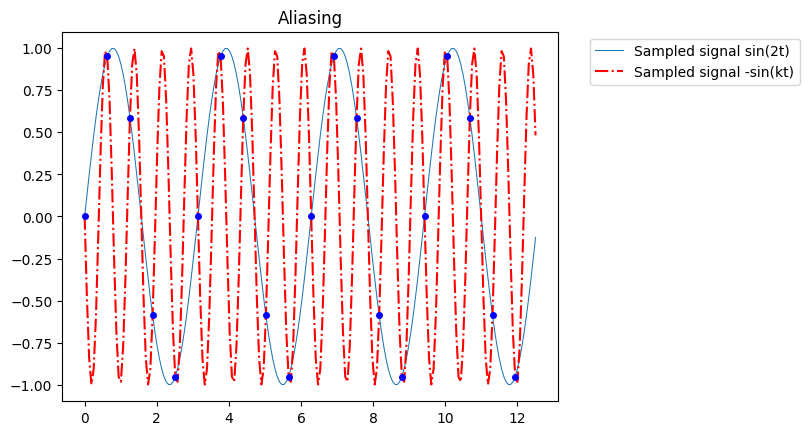

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True]


In [28]:
y = np.linspace(0,4*np.pi, 21)[:-1]

plt.plot(t, np.sin(2*t), lw = 0.75, label = "Sampled signal sin(2t)")

# ========= YOUR CODE STARTS HERE ========= #

# plug in proper k below
k = 8  # Alias frequency: -sin(8t) = sin(2t) at sample points
# ========== YOUR CODE ENDS HERE ========== #

plt.plot(t, -np.sin(k*t), "r-.", label = "Sampled signal -sin(kt)")
plt.plot(y, np.sin(2*y), "bo", markersize = 4)
plt.title('Aliasing')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

print(np.isclose(np.sin(2*y), -np.sin(8*y)))

Sampling rate = N/T = 20/(4π) approx. =  1.59 Hz

At sample points: y_j = j × (4π/20) = j × (π/5) for j=0,1,...,19

We want: -sin(k × y_j) = sin(2 × y_j) for all j

This means: sin(k × j × π/5) = -sin(2j × π/5) = sin(-2j × π/5)

Using the periodicity of sine with period 2π:

k × j × π/5 ≡ -2j × π/5 (mod 2π)
k × j ≡ -2j (mod 10)
k ≡ -2 (mod 10)
k = 8


**Verification:**

sin(8j × π/5) = sin(2πj - 2j × π/5) = sin(-2j × π/5) = -sin(2j × π/5)

Now find aliasing to the initial signal; it should be a linear combination of two sine signals $\sin(\omega t)$ with $\omega$ different from $2$ and $3$

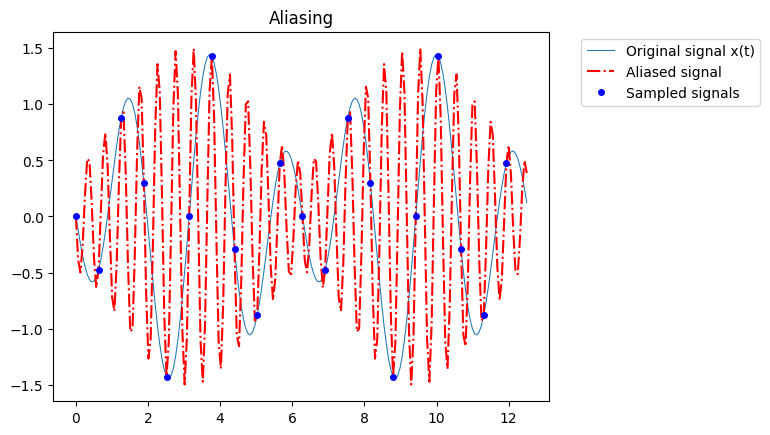

In [29]:
plt.plot(t, x, lw = 0.75, label = "Original signal x(t)")

# ========= YOUR CODE STARTS HERE ========= #
# Aliased frequencies: ω=2 -> ω=12, ω=3 -> ω=13
x_aliased = 0.5*np.sin(12*t) - np.sin(13*t)
plt.plot(t, x_aliased  , "r-.", label = "Aliased signal")
plt.plot(y, signal(y)  , "bo", markersize = 4, label = "Sampled signals")
# ========== YOUR CODE ENDS HERE ========== #

plt.title('Aliasing')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

In [30]:
# ========= YOUR CODE STARTS HERE ========= #
np.isclose(signal(y), 0.5*np.sin(12*y) - np.sin(13*y) )
# ========== YOUR CODE ENDS HERE ========== #

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

With sampling spacing delta t = π/5, frequencies separated by **10 rad/s** are indistinguishable:

**For 0.5sin(2t):**
- Original: ω = 2
- Alias: ω = 2 + 10 = 12
- Check: sin(12 × jπ/5) = sin(2πj + 2jπ/5) = sin(2jπ/5)

**For -sin(3t):**
- Original: ω = 3  
- Alias: ω = 3 + 10 = 13
- Check: sin(13 × jπ/5) = sin(2πj + 3jπ/5) = sin(3jπ/5)

**Aliased signal:** 0.5sin(12t) - sin(13t) with ω ∈ {12, 13} != {2, 3}

---

With 20 samples over 4π seconds (sampling rate 1.59 Hz, Nyquist limit ~0.8 Hz), we
showed that high-frequency signals can masquerade as low-frequency ones when sampled
below the Nyquist rate. Specifically, -sin(8t) is indistinguishable from sin(2t) at
our sample points, and the high-frequency combination 0.5sin(12t) - sin(13t) perfectly
mimics our original signal x(t) = 0.5sin(2t) - sin(3t) at all 20 samples. This
ambiguity arises because frequencies separated by 10 rad/s (= 2π/Δt) produce identical
sample values. The results confirm that adequate sampling rate (exceeding twice the
maximum frequency) is essential for unique signal reconstruction and preventing
aliasing artifacts.

---

## Task 3. Fourier transform and FFT (1 pt)

Another reason why spurious frequencies appeared in ***Task 1.2*** is due to integration error. When we replaced the integrals for calculating the Fourier coefficinets $a_k$ and $b_k$ by the Riemann integral sums, aliasing for sinusoids with high frequencies led to results identical with those for smaller frequencies, although the actual $a_k$ and $b_k$ are equal to zero for smooth signal and are very small for noisy signal.

In other words, when replacing integrals with sums, we actually moved the object of study from the analog signals in $L_2[0,4\pi]$ to digital signals in $\mathbb{R}^N$. Certainly, $N$ sampled cosines and $N$ sampled sines formed linearly dependent vectors in $\mathbb{R}^N$, and that is why using all of them to reconstruct the original signal $\mathbf{x}_\mathrm{noise}$ failed.

When working with digital signals in $\mathbb{R}^N$, we only need $N$ basis vectors. Observe that sampled cosines are <font color="red">*even*</font> functions with respect to mid-point, i.e., $\cos(t_j) = \cos(t_{N-j})$; likewise, sines are <em><font color="red">odd</font></em> with respect to the mid-point. Another observation is that neither sampled cosines nor sampled sines form orthogonal sets. For that reason, a more convenient orthogonal basis in $\mathbb{C}^N$ is given by the sampled exponentials $\mathrm{e}^{2\pi \mathrm{i} k t/T}$, $k=0,1,\dots,N-1$: $$\mathbf{e}_k:=\bigl(1, \mathrm{e}^{2\pi \mathrm{i}k t_1/T}, \dots, \mathrm{e}^{2\pi \mathrm{i}t_{N-1}/T}\bigr)$$
Observe that the exponential function $\mathrm{e}^{2\pi \mathrm{i} k t/T}$ is a pure complex harmonics of frequency $k/T$ Hz.

Every vector $\mathbf{x} \in \mathbb{C}^N$ can be represented in this basis in the standard way: $$\mathbf{x} = \sum_k c_k \mathbf{e}_k, \qquad c_k = \frac{\langle \mathbf{x}, \mathbf{e}_k\rangle}{\langle \mathbf{e}_k, \mathbf{e}_k\rangle} = \frac1N\sum_j x_j \mathrm{e}^{- 2\pi \mathrm{i}t_{j}/T} \tag{4}$$
The $c_k$ are <font color = "red">complex Fourier coefficients</font> of $\mathbf{x}$, and the mapping
$$
   \mathbf{x} \mapsto (c_k)_{k=0}^{N-1}
$$
is the <font color = "red">Fourier transform</font>. While the direct approach of calculating $c_k$ requires $O(N^2)$ flops, the ***Fast Fourier transform (FFT)*** performs this in $O(N\log N)$ flops. Given that a standard audio signal of duration 1 second is sampled $N = 44\,100$ times, FFT gives a significant gain in time efficiency.

---
### Task 3.1

- Calculate the Fourier coefficients $c_k$ of the noisy signal $\mathbf{x}_{\mathrm{noise}}$ via (4) and plot their real and imaginary parts. Do you see any pattern? Both real and imaginary parts have mid-point symmetry. Explain which are even with respect to the midpoint, and which are odd
- Calculate $c_k$ using the $\texttt{fft}$ function and plot their real and imaginary parts. Explain why the real parts are quite small but the imaginary ones have spikes (for what $k$)?
- Compare the results; take into account that the $\texttt{fft}$ function does not divide the coefficients by $N$; instead, the scaling is applied to the reconstructed image during the inverse FFT step $\texttt{ifft}$
- Detect the indices $k$ for which $|c_k|$ are large and explain the finding
---

<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-504537501.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Fourier coefficients of the noisy signal $\mathbf{x}_{\mathrm{noise}}$')


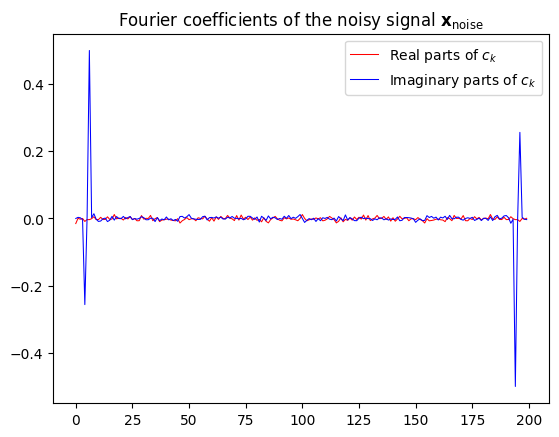

In [31]:
# Complex Fourier coefficients calculated directly

# ========= YOUR CODE STARTS HERE ========= #
compl_exp = np.exp(-2j * np.pi * np.arange(N).reshape(N, 1) * np.arange(N) / N)  #  N x N matrix of exponents
c = (compl_exp @ x_noise) / N                                                   #  complex Fourier coefficients on the noisy signal
# ========== YOUR CODE ENDS HERE ========== #

plt.plot(c.real.T, 'r', lw = 0.75, label = "Real parts of $c_k$")
plt.plot(c.imag.T, 'b', lw = 0.75, label = "Imaginary parts of $c_k$")
plt.title('Fourier coefficients of the noisy signal $\mathbf{x}_{\mathrm{noise}}$')
plt.legend()
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2431976465.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Fourier coefficients of the noisy signal $\mathbf{x}_{\mathrm{noise}}$ via FFT')


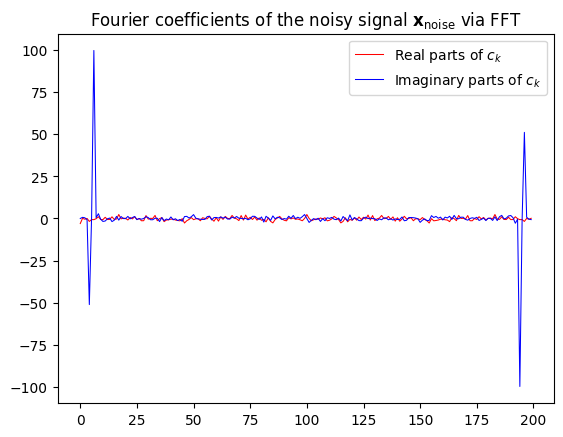

In [32]:
# Complex Fourier coefficients via FFT
freq = fft(x_noise)

plt.plot(freq.real, 'r', lw = 0.75, label = "Real parts of $c_k$")
plt.plot(freq.imag, 'b', lw = 0.75, label = "Imaginary parts of $c_k$")
plt.title('Fourier coefficients of the noisy signal $\mathbf{x}_{\mathrm{noise}}$ via FFT')
plt.legend()
plt.show()

In [33]:
np.allclose(c, freq/200)

True

---    
#### **Remark**
Recall the Euler formula
$$ \sin(\alpha x) =  \frac{\mathrm{e}^{\mathrm{i}\alpha x} - \mathrm{e}^{-\mathrm{i}\alpha x}}{2\mathrm{i}};$$
this gives the Fourier coefficients of $\sin(\alpha x)$. Noting that $c_{-k}$ can identified with $c_{N-k}$, this sheds light on the distribution of the Fourier coefficients for the signal $\mathbf{x}$    


---

Upon calculating the Fourier coefficients $c_k$ for the noisy signal $x_{\text{noise}}$, we observed the expected **conjugate symmetry** for a real-valued signal. The real part $Re(c_k)$ is **even** (symmetric) around the midpoint $N/2$, while the imaginary part $Im(c_k)$ is **odd** (anti-symmetric).

The plots show that the real part of the coefficients is small, representing the random noise. In contrast, the imaginary part has large spikes at indices **$k=2$** and **$k=20$**. This is because the underlying clean signal, $\sin(t) + \sin(10t)$, is an odd function, which has a purely imaginary Fourier transform.

Both the manual calculation and the fft function produced identical results, with the fft output simply being an **unnormalized** version (scaled by $N=200$) of our manual c.

The dominant frequencies were successfully detected at the indices where $|c_k|$ is largest: **$k=2, 20, 180,$ and $198$**. The indices $2$ and $20$ correspond to the signal's primary frequencies, while $180$ ($N-20$) and $198$ ($N-2$) are their necessary symmetric counterparts.


---





---
### Task 3.2

- Make sure that the noisy signal $\mathbf{x}_\mathrm{noise}$ is perfectly reconstructed via $\mathtt{ifft}$
- Reconstruct the noisy signal $\mathbf{x}_\mathrm{noise}$ directly and compare with the original
- Set the coefficients nos. 11 to 189 to zero and reconstruct the signal. Comment on the observed effect
- Take the smooth signal $\mathbf{x}$ and construct the Fourier coefficients using $\texttt{fft}$. Plot the real and imaginary parts and comment on the difference with the noiseless case
---

In [34]:
np.allclose(x_noise, ifft(freq))

True

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1534722736.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Signal $\mathbf{x}_{\mathrm{noise}}$ and its direct reconstruction')
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


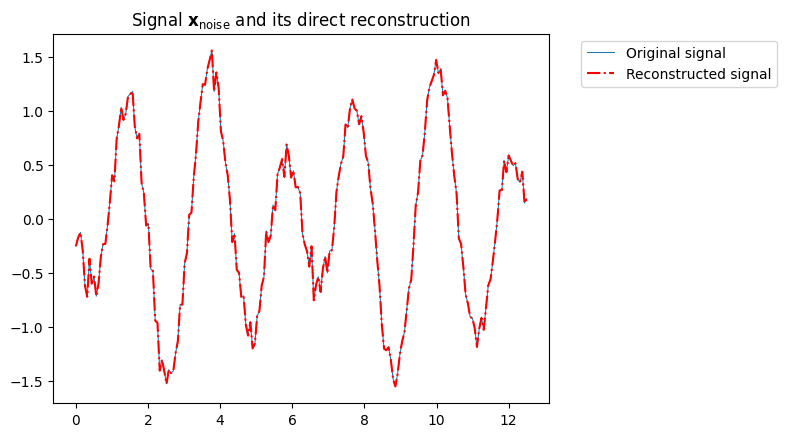

In [35]:
# ========= YOUR CODE STARTS HERE ========= #
#  Now reconstruct x_noise directly (without IFFT)
x_rec_F = np.matmul(c, compl_exp.conj() )   #  direct reconstruction of the signal
# ========= YOUR CODE ENDS HERE ========= #


plt.plot(t, x_noise, lw = 0.75, label = "Original signal")
plt.plot(t, x_rec_F.T, "r-.", label = "Reconstructed signal")
plt.title('Signal $\mathbf{x}_{\mathrm{noise}}$ and its direct reconstruction')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

Make sure the reconstructions (via FFT and direct) return original signal:


In [36]:
x_rec_FFT = ifft(freq)
np.allclose(x_noise, x_rec_FFT)

True

In [37]:
np.allclose(x_noise, x_rec_F)

True

Set all frequencies but for the first and the last $n$ (with say $n=10$ to zero and observe the result

In [38]:
freq_smoothed = freq.copy()
# ========= YOUR CODE STARTS HERE ========= #
freq_smoothed[10 : -10] = 0
# ========= YOUR CODE ENDS HERE ========= #

In [39]:
np.sum(np.isclose(x_noise, ifft(freq_smoothed), rtol = 0.05))

np.int64(51)

<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-863250446.py:6: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Signal $\mathbf{x}_{\mathrm{noise}}$ and its reconstruction')


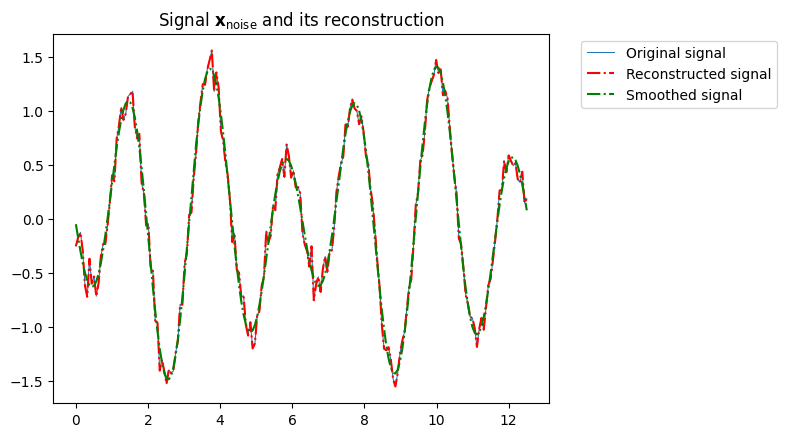

In [40]:
#  Plot the original noisy and smoothed signals

plt.plot(t, x_noise, lw = 0.75, label = "Original signal")
plt.plot(t, ifft(freq), 'r-.', label = "Reconstructed signal")
plt.plot(t, ifft(freq_smoothed), 'g-.', label = "Smoothed signal")
plt.title('Signal $\mathbf{x}_{\mathrm{noise}}$ and its reconstruction')
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.show()

Plot the Fourier coefficients (real and imaginary parts) of the initial smooth signal and compare to those in $\mathtt{freq\_smoothed}$


<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-1804681029.py:8: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title('Coefficients of Initial Smooth Signal $\mathbf{x}$')
/tmp/ipython-input-1804681029.py:14: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title('Coefficients after Smoothing $\mathbf{freq\_smoothed}$')


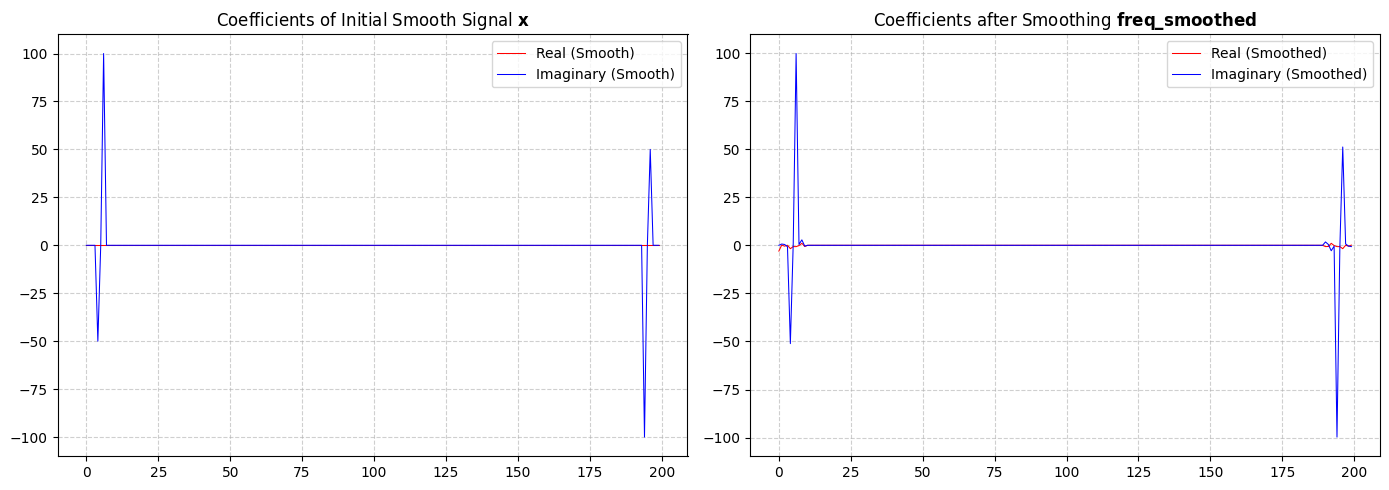

In [41]:
# ========= YOUR CODE STARTS HERE ========= #
freq_x = np.fft.fft(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(freq_x.real, 'r', lw=0.75, label="Real (Smooth)")
ax1.plot(freq_x.imag, 'b', lw=0.75, label="Imaginary (Smooth)")
ax1.set_title('Coefficients of Initial Smooth Signal $\mathbf{x}$')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

ax2.plot(freq_smoothed.real, 'r', lw=0.75, label="Real (Smoothed)")
ax2.plot(freq_smoothed.imag, 'b', lw=0.75, label="Imaginary (Smoothed)")
ax2.set_title('Coefficients after Smoothing $\mathbf{freq\_smoothed}$')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
# ========= YOUR CODE ENDS HERE ========= #

---

#### **Your explanations for Task 3.2 come here**

---

## 4. Conclusions (0.3 pts)

Summarize in a few sentences what you have learned and achieved by completing the tasks of this assignment

---

\### **YOUR ANSWER HERE** \###

---